**Demand for Grants 2026-27 Analysis: Environment, Forests and Climate Change**

**Pollution Scheme: Budget Allocation vs Actual Spending**

This notebook analyses the allocation and utilisation of funds under the Control of Pollution scheme, based on the PRS Legislative Research analysis of the Demand for Grants 2026-27 for the Ministry of Environment, Forest and Climate Change.

Question to pursue:
How much money is allocated to the Control of Pollution scheme, and how much of that money is actually spent?

Importing the libraries

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

Storing the webpage URL

In [4]:
url = "https://prsindia.org/budgets/parliament/demand-for-grants-2026-27-analysis-environment-forests-and-climate-change"

Requesting the webpage

In [5]:
response = requests.get(url)

In [6]:
response.status_code

200

Parse the webpage

In [7]:
soup = BeautifulSoup(response.text, "html.parser")

**Finding the Tables**

In [8]:
tables = soup.find_all("table")

In [9]:
len(tables)

22

In [11]:
type(tables)

bs4.element.ResultSet

In [12]:
type(tables[0])

bs4.element.Tag

In [13]:
for i, table in enumerate(tables):
    print("TABLE", i)
    print(table)
    print()

TABLE 0
<table cellspacing="0" class="MsoTableGrid" style="background:#f2f2f2; border-collapse:collapse; border:none">
<tbody>
<tr>
<td style="background-color:#f2f2f2; height:103px; vertical-align:top; width:757px">
<p><span style="font-family:Times New Roman,Times,serif"><span style="font-size:16px"><span style="color:black"><strong>Highlights</strong></span></span></span></p>
<ul style="list-style-type:square">
<li>
<p><span style="font-family:Times New Roman,Times,serif"><span style="font-size:16px"><span style="color:black">Budget utilisation was low for several schemes, including the Control of Pollution scheme and Mission for Green India. </span></span></span></p>
</li>
<li>
<p><span style="font-family:Times New Roman,Times,serif"><span style="font-size:16px"><span style="color:black">Under Integrated Development of Wildlife Habitats scheme, 72% of the budget has been allocated for Project Tiger and Elephant.  </span></span></span></p>
</li>
<li>
<p><span style="font-family:Time

**Finding the Control of Pollution table**

In [14]:
for i, table in enumerate(tables):
    text = table.get_text(" ", strip=True)
    
    if "Control of Pollution" in text:
        print("Found in TABLE", i)

Found in TABLE 0
Found in TABLE 2


In [15]:
print(tables[0].get_text(" | ", strip=True))

Highlights | Budget utilisation was low for several schemes, including the Control of Pollution scheme and Mission for Green India. | Under Integrated Development of Wildlife Habitats scheme, 72% of the budget has been allocated for Project Tiger and Elephant. | As of March 2023, CPCB had 33% vacancies. | India reduced the emission intensity of GDP from 2005 levels by 36% in 2020 and reached renewable capacity of 51% as of December 2025. | The number of polluted rivers stretches declined from 351 in 2017–18 to 296 in 2022–23, but in 2024, biochemical oxygen demand exceeded prescribed limits at 146 river monitoring stations.


In [16]:
print(tables[2].get_text(" | ", strip=True))

2023-24 | 2025-26 RE | 2026-27 BE | % change | Control of Pollution scheme | 191 | 1,452 | 1,308 | -11% | Environment, Forestry and Wildlife | 606 | 392 | 651 | 40% | Autonomous Bodies | 439 | 391 | 416 | 6% | Statutory and Regulatory Bodies | 194 | 195 | 221 | 11% | Environmental Knowledge and Capacity Building | 100 | 69 | 103 | 33% | National Coastal Mission | 8 | 8 | 10 | 24%


**Saving Table 2**

In [17]:
pollution_table = tables[2]

To find all the rows (<tr>) inside  the Control of Pollution table and to store them in rows.

In [20]:
rows = pollution_table.find_all("tr")

To print each row separately, so we can see the column headings and the Control of Pollution Allocation figures.

In [23]:
for row in rows:
    print(row.get_text(" | ", strip=True))

2023-24 | 2025-26 RE | 2026-27 BE | % change
Control of Pollution scheme | 191 | 1,452 | 1,308 | -11%
Environment, Forestry and Wildlife | 606 | 392 | 651 | 40%
Autonomous Bodies | 439 | 391 | 416 | 6%
Statutory and Regulatory Bodies | 194 | 195 | 221 | 11%
Environmental Knowledge and Capacity Building | 100 | 69 | 103 | 33%
National Coastal Mission | 8 | 8 | 10 | 24%


**we need to find the actual expenditure figures**

In [24]:
for i, table in enumerate(tables):
    if "actual" in table.get_text(" ", strip=True).lower():
        print("TABLE", i)

TABLE 1


In [25]:
print(tables[1].get_text(" | ", strip=True))

2023-24 Actual | 2025-26 Revised | 2026-27 Budget | % Change | Revenue | 2,131 | 3,307 | 3,537 | 7% | Capital | 89 | 174 | 223 | 22% | Total | 2,220 | 3,482 | 3,759 | 7%


**To save all the webpage's text into a variable called page_text**

In [27]:
page_text = soup.get_text(" ", strip=True)

**To find where the word utilisation appears in the webpage text**

In [28]:
print(page_text.lower().find("utilisation"))

1515


In [29]:
print(page_text[1200:2200])

ats COVID-19 LAMP About the LAMP Fellowship How to Apply Life at LAMP Videos Meet our
Fellows Get in touch Careers Budgets Parliament Demand for Grants 2026-27 Analysis : Environment, Forests and Climate Change Demand for Grants 2026-27 Analysis : Environment, Forests and Climate Change Open PDF Highlights Budget utilisation was low for several schemes, including the Control of Pollution scheme and Mission for Green India. Under Integrated Development of Wildlife Habitats scheme, 72% of the budget has been allocated for Project Tiger and Elephant. As of March 2023, CPCB had 33% vacancies. India reduced the emission intensity of GDP from 2005 levels by 36% in 2020 and reached renewable capacity of 51% as of December 2025. The number of polluted rivers stretches declined from 351 in 2017–18 to 296 in 2022–23, but in 2024, biochemical oxygen demand exceeded prescribed limits at 146 river monitoring stations. The Ministry of Environment, Forest and Climate Change (MoEFCC) is responsible fo

**The positions where “Control of Pollution” appears**

In [31]:
print([i for i in range(len(page_text)) if page_text.lower().startswith("control of pollution", i)])

[1570, 2499, 2561, 3537, 4181, 4875, 31306, 31362, 32239, 32572, 32722, 33183, 41128]


**To find the text around that occurrence and locate the actual expenditure/utilisation information**

In [33]:
print(page_text[30500:32000])

ear. Sources: National Centre for Coastal Research, 2022; PRS. The Mangrove Initiative for Shoreline Habitats and Tangible Incomes (MISHTI) was launched in June 2023 to promote and restore mangroves and to enhance the resilience of the coastal ecosystem. [62] The MISHTI program includes plantation and restoration, and the support activities, which include livelihood diversification and promotion of ecotourism through Self-Help Groups.  Funding for the scheme is provided through CAMPA funds. As of 2023, India has 4,992 sq. km of mangrove cover. [63] This is a reduction of 0.15% from 2021, when mangrove cover was 4,999 sq. km.  As of 2024-25, 22,560 hectares of mangrove plantation and restoration has been undertaken. [64] Pollution Control Central Pollution Control Board The Water (Prevention and Control of Pollution) Act, 1974 and Air (Prevention and Control of Pollution) Act, 1981 provide for establishment of the Central Pollution Control Board (CPCB). [65] CPCB advises the central gov

In [34]:
print(page_text[32000:33500])

ies, and coastal waters remain inadequately monitored, and gaps in quality assurance affect the reliability of environmental data used for policy and action plans.68 The Ministry of Environment, Forest & Climate Change is implementing the Control of Pollution scheme. [69] The scheme has four components: (i) Assistance for Abatement of Pollution to weaker State Pollution Control Boards, (ii) National Clean Air Programme, (iii) Environmental Monitoring Network Programme, and (iv) Research and Outreach Programmes.69 In 2026-27, Rs 1,091 crore has been allocated to the Control of Pollution scheme, which is 16% lower than the revised estimates of 2025-26 (Rs 1,300 crore). Table 8: Allocation and Utilisation under the Control of Pollution scheme (in Rs crore) Year Allocated Utilised % Utilised 2022-23 460 600 130% 2023-24 756 845 112% 2024-25 859 16 2% 2025-26 854 1,300 152% 2026-27 1,091 - - Note: Revised estimates taken as actuals for 2025-26. Sources: Demand for Grants, 2026-27, Ministry 

**to extract Table 8 directly from the webpage**

In [36]:
table_8 = tables[8]

**To extract its rows so we can see the table structure: To get every row from Table 8 and store them in rows**

In [40]:
rows = table_8.find_all("tr")

In [41]:
for row in rows:
    print(row.get_text(" | ", strip=True))

National Green Tribunal | The National Green Tribunal (NGT) adjudicates cases relating to environmental protection, conservation of forests and natural resources, and enforcement of environmental laws, with the objective of providing speedy environmental justice. Currently, there are five benches of the NGT in Delhi, Pune, Bhopal, Chennai and Kolkata. | As of November 2025, data furnished to Parliament shows that the NGT’s five benches collectively have over 5,400 pending cases, with significant backlogs at several benches. | [30] | The principal bench in New Delhi reported 1,939 pending cases, while Pune had 1,933 pending cases.30  The NGT’s statutory composition provides for at least ten judicial members and ten expert members.  As of 2025, there were six vacant posts of judicial members and four vacant posts of expert members.30


To search all the scraped HTML tables for the column names Allocated and Utilised.


In [42]:
for i, table in enumerate(tables):
    if "Allocated" in table.get_text(" ", strip=True) and "Utilised" in table.get_text(" ", strip=True):
        print("TABLE", i)

TABLE 12


In [43]:
pollution_utilisation_table = tables[12]

In [44]:
rows = pollution_utilisation_table.find_all("tr")

In [45]:
for row in rows:
    print(row.get_text(" | ", strip=True))

Year | Allocated | Utilised | % Utilised
2022-23 | 460 | 600 | 130%
2023-24 | 756 | 845 | 112%
2024-25 | 859 | 16 | 2%
2025-26 | 854 | 1,300 | 152%
2026-27 | 1,091 | - | -


**creating Pandas Dataframe**

In [48]:
data = []

for row in rows[1:]:
    cells = row.find_all(["td", "th"])
    data.append([cell.get_text(strip=True) for cell in cells])

 **Turning extracted data into a Pandas DataFrame**

In [49]:
pollution_df = pd.DataFrame(
    data,
    columns=["Year", "Allocated", "Utilised", "Percent_Utilised"]
)

In [50]:
pollution_df

,Year,Allocated,Utilised,Percent_Utilised
0,2022-23,460,600,130%
1,2023-24,756,845,112%
2,2024-25,859,16,2%
3,2025-26,854,"1,300",152%
4,2026-27,"1,091",-,-


In [51]:
pollution_df.dtypes

Year                str
Allocated           str
Utilised            str
Percent_Utilised    str
dtype: object

**Cleaning the Data**

In [52]:
pollution_df["Allocated"] = pollution_df["Allocated"].str.replace(",", "").astype(float)

In [53]:
pollution_df.dtypes

Year                    str
Allocated           float64
Utilised                str
Percent_Utilised        str
dtype: object

In [54]:
pollution_df["Utilised"] = pollution_df["Utilised"].str.replace(",", "")

In [55]:
pollution_df["Utilised"] = pollution_df["Utilised"].replace("-", pd.NA)

In [56]:
pollution_df["Utilised"] = pollution_df["Utilised"].astype(float)

In [57]:
pollution_df.dtypes

Year                    str
Allocated           float64
Utilised            float64
Percent_Utilised        str
dtype: object

In [58]:
pollution_df["Percent_Utilised"] = pollution_df["Percent_Utilised"].str.replace("%", "")

In [59]:
pollution_df["Percent_Utilised"] = pollution_df["Percent_Utilised"].astype(float)

ValueError: could not convert string to float: '-'

In [60]:
pollution_df["Percent_Utilised"] = pollution_df["Percent_Utilised"].replace("-", pd.NA)

In [61]:
pollution_df["Percent_Utilised"] = pollution_df["Percent_Utilised"].astype(float)

In [62]:
pollution_df.dtypes

Year                    str
Allocated           float64
Utilised            float64
Percent_Utilised    float64
dtype: object

In [63]:
pollution_df

,Year,Allocated,Utilised,Percent_Utilised
0,2022-23,460.0,600.0,130.0
1,2023-24,756.0,845.0,112.0
2,2024-25,859.0,16.0,2.0
3,2025-26,854.0,1300.0,152.0
4,2026-27,1091.0,NaN,NaN


In [64]:
pollution_df["Gap"] = pollution_df["Allocated"] - pollution_df["Utilised"]

In [65]:
pollution_df

,Year,Allocated,Utilised,Percent_Utilised,Gap
0,2022-23,460.0,600.0,130.0,-140.0
1,2023-24,756.0,845.0,112.0,-89.0
2,2024-25,859.0,16.0,2.0,843.0
3,2025-26,854.0,1300.0,152.0,-446.0
4,2026-27,1091.0,NaN,NaN,NaN


**To identify the largest positive allocation-utilisation gap**

In [67]:
pollution_df["Gap"].max()

np.float64(843.0)

In [68]:
pollution_df.loc[pollution_df["Gap"].idxmax()]

Year                2024-25
Allocated             859.0
Utilised               16.0
Percent_Utilised        2.0
Gap                   843.0
Name: 2, dtype: object

**total allocation and total utilisation for 2022-23 to 2025-26**

In [69]:
pollution_df[["Allocated", "Utilised"]].iloc[:4].sum()

Allocated    2929.0
Utilised     2761.0
dtype: float64

**the overall utilisation rate across these four years**

In [70]:
(2761 / 2929) * 100

94.26425401160806

In [71]:
((1091 - 854) / 854) * 100

27.751756440281028

**Finding the percentage increase in the 2026-27 allocation compared with the 2024-25 allocation, because 2024-25 is a key low-utilisation year**

In [72]:
((1091 - 859) / 859) * 100

27.0081490104773

**Utilisation increase (in percentage) from 2024-25 to 2025-26**

In [73]:
((1300 - 16) / 16) * 100

8025.0

**A chart comparing allocated vs utilised across the years**
**Because 2026-27 has no utilisation figure, it has been left out of this chart**

In [75]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [76]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 3.6 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.5 MB 3.2 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/9.5 MB 4.1 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.5 MB 4.7 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.5 MB 4.9 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 5.2 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.5 MB 5.1 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.5 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 5.1 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------- ---------------------- 1.0/2.3 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.7 MB/s  0:00:00
   -----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [77]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


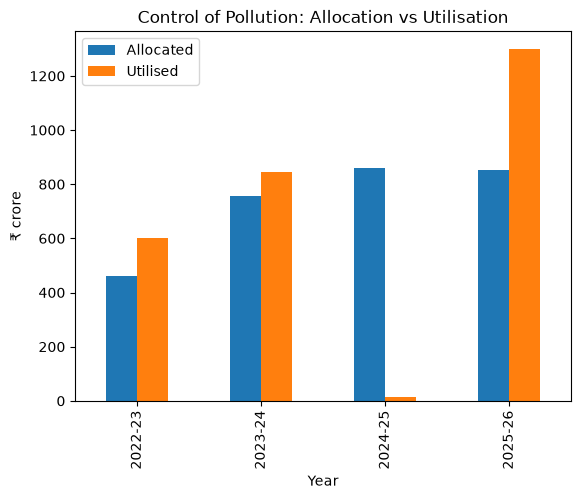

In [78]:
pollution_df.iloc[:4].plot(
    x="Year",
    y=["Allocated", "Utilised"],
    kind="bar"
)

plt.title("Control of Pollution: Allocation vs Utilisation")
plt.xlabel("Year")
plt.ylabel("₹ crore")
plt.show()

**utilisation rate for each year**

In [79]:
pollution_df["Calculated_Utilisation"] = (
    pollution_df["Utilised"] / pollution_df["Allocated"] * 100
)

In [80]:
pollution_df[["Year", "Allocated", "Utilised", "Percent_Utilised", "Calculated_Utilisation"]]

,Year,Allocated,Utilised,Percent_Utilised,Calculated_Utilisation
0,2022-23,460.0,600.0,130.0,130.434783
1,2023-24,756.0,845.0,112.0,111.772487
2,2024-25,859.0,16.0,2.0,1.862631
3,2025-26,854.0,1300.0,152.0,152.224824
4,2026-27,1091.0,NaN,NaN,NaN


**a cleaner rounded utilisation rate**

In [81]:
pollution_df["Calculated_Utilisation"] = pollution_df["Calculated_Utilisation"].round(1)

**a line chart of utilisation over time**

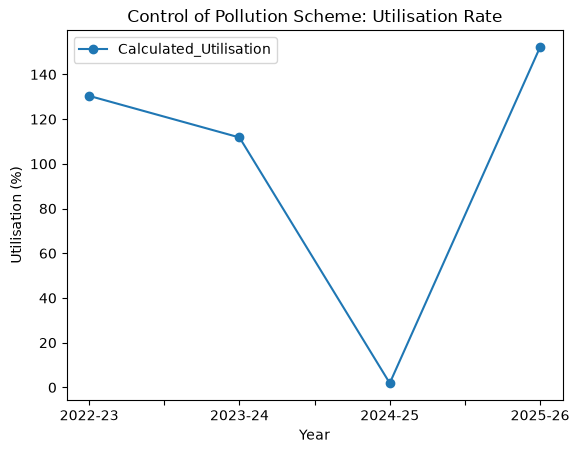

In [82]:
pollution_df.iloc[:4].plot(
    x="Year",
    y="Calculated_Utilisation",
    kind="line",
    marker="o"
)

plt.title("Control of Pollution Scheme: Utilisation Rate")
plt.xlabel("Year")
plt.ylabel("Utilisation (%)")
plt.show()

**the 2024-25 shortfall as a percentage of the allocation**

In [83]:
(843 / 859) * 100

98.1373690337602

**How much higher was the 2026-27 allocation than the 2025-26 allocation?**

In [85]:
1091 - 854

237

**Key Finding: Sharp Variation in Pollution Control Fund Utilisation**

The Control of Pollution scheme shows significant year-to-year variation between budget allocation and utilisation.

In 2024-25, ₹859 crore was allocated to the scheme, but only ₹16 crore was utilised, representing just 2% of the allocation. This left an allocation-utilisation gap of ₹843 crore, with approximately 98% of the allocated amount remaining unutilised during the year.

Utilisation rose sharply in 2025-26, reaching ₹1,300 crore against an allocation of ₹854 crore. PRS notes that this table treats the Revised Estimate for 2025-26 as actual expenditure.

For 2026-27, ₹1,091 crore has been allocated to the Control of Pollution scheme. This is ₹237 crore, or about 27.8%, higher than the 2025-26 allocation.

The data therefore points to substantial fluctuations in the utilisation of pollution-control funds rather than a consistent relationship between annual allocation and spending.

**minimum (lowest) utilisation rate**

In [87]:
pollution_df.loc[pollution_df["Percent_Utilised"].idxmin()]

Year                      2024-25
Allocated                   859.0
Utilised                     16.0
Percent_Utilised              2.0
Gap                         843.0
Calculated_Utilisation        1.9
Name: 2, dtype: object

**the highest utilisation rate**

In [89]:
pollution_df.loc[pollution_df["Percent_Utilised"].idxmax()]

Year                      2025-26
Allocated                   854.0
Utilised                   1300.0
Percent_Utilised            152.0
Gap                        -446.0
Calculated_Utilisation      152.2
Name: 3, dtype: object

In [90]:
pollution_df.loc[3, "Percent_Utilised"] - pollution_df.loc[2, "Percent_Utilised"]

np.float64(150.0)

**Finding the biggest allocation**

In [91]:
pollution_df.loc[pollution_df["Allocated"].idxmax()]

Year                      2026-27
Allocated                  1091.0
Utilised                      NaN
Percent_Utilised              NaN
Gap                           NaN
Calculated_Utilisation        NaN
Name: 4, dtype: object

**Find the lowest allocation**

In [92]:
pollution_df.loc[pollution_df["Allocated"].idxmin()]

Year                      2022-23
Allocated                   460.0
Utilised                    600.0
Percent_Utilised            130.0
Gap                        -140.0
Calculated_Utilisation      130.4
Name: 0, dtype: object

**The absolute increase in allocation from 2022-23 to 2026-27**

In [93]:
pollution_df.loc[4, "Allocated"] - pollution_df.loc[0, "Allocated"]

np.float64(631.0)

**percentage increase**

In [95]:
((1091 - 460) / 460) * 100

137.17391304347825

**calculate the allocation trend year by year**

In [96]:
pollution_df[["Year", "Allocated"]]

,Year,Allocated
0,2022-23,460.0
1,2023-24,756.0
2,2024-25,859.0
3,2025-26,854.0
4,2026-27,1091.0


**the year-on-year allocation change**

In [97]:
pollution_df["Allocation_Change"] = pollution_df["Allocated"].pct_change() * 100

In [98]:
pollution_df[["Year", "Allocated", "Allocation_Change"]]

,Year,Allocated,Allocation_Change
0,2022-23,460.0,NaN
1,2023-24,756.0,64.347826
2,2024-25,859.0,13.624339
3,2025-26,854.0,-0.582072
4,2026-27,1091.0,27.751756


**Story Pitch**

The analysis shows that higher budget allocations to the Control of Pollution scheme have not consistently translated into spending. Between 2022-23 and 2026-27, the allocation rose from ₹460 crore to ₹1,091 crore, a rise of 137.2%.

However, utilisation varied substantially across the years. In 2024-25, only ₹16 crore was utilised against an allocation of ₹859 crore. This represented a utilisation rate of just 2% and an allocation-utilisation gap of ₹843 crore.

Utilisation increased sharply in 2025-26 to ₹1,300 crore, or 152% of the ₹854 crore allocation. (PRS notes that the Revised Estimate for 2025-26 is treated as actuals in the table, so this figure should be interpreted accordingly.)

For 2026-27, ₹1,091 crore has been allocated to the Control of Pollution scheme. Since utilisation data for 2026-27 is not yet available, the effectiveness of this allocation cannot be assessed.

The data points to significant year-to-year fluctuations in their utilisation. The sharp fall to 2% utilisation in 2024-25 is the key finding for further reporting and investigation.

The story will look at why pollution-control spending has been so inconsistent despite rising allocations.
